# House price (statistics)

In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv('house_price.csv')

In [5]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


In [7]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [8]:
df.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13195    False
13196    False
13197    False
13198    False
13199     True
Length: 13200, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(1049)

In [11]:
df = df.drop_duplicates()

## Create price per sqft

In [12]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

##  Mean and Standard deviation

In [13]:
mean = df['price_per_sqft'].mean()
std = df['price_per_sqft'].std()

upper = mean + 3*std
lower = mean - 3*std

df_std = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

## Percentile method

In [14]:
lower = df['price_per_sqft'].quantile(0.01)
upper = df['price_per_sqft'].quantile(0.99)

df_percentile = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

## IQR(Inter quartile range method)

In [15]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df[(df['price_per_sqft'] >= lower) & (df['price_per_sqft'] <= upper)]

## Z Score method

In [16]:
from scipy import stats

z = np.abs(stats.zscore(df['price_per_sqft']))

df_z = df[z < 3]

## Box Plot Comparison

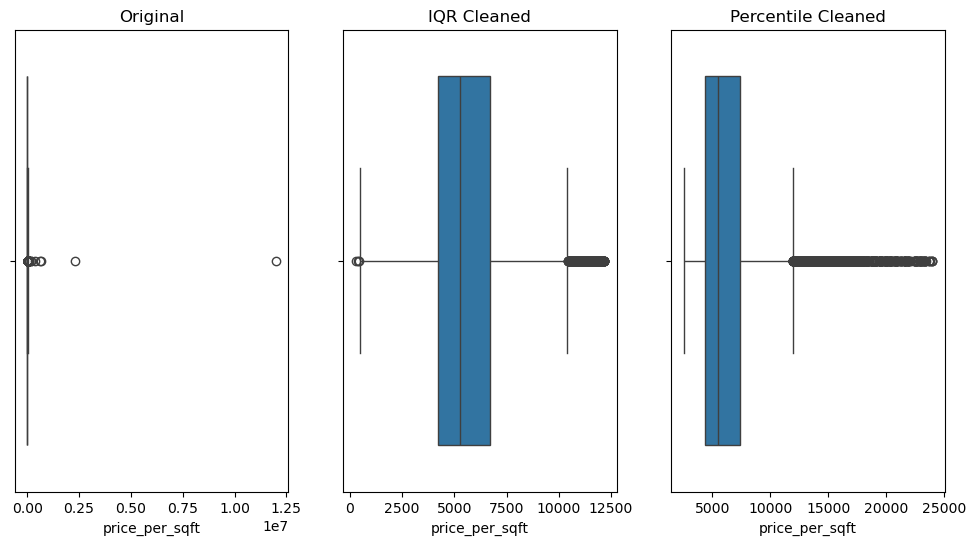

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
sns.boxplot(x=df['price_per_sqft'])
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(x=df_iqr['price_per_sqft'])
plt.title("IQR Cleaned")

plt.subplot(1,3,3)
sns.boxplot(x=df_percentile['price_per_sqft'])
plt.title("Percentile Cleaned")

plt.show()

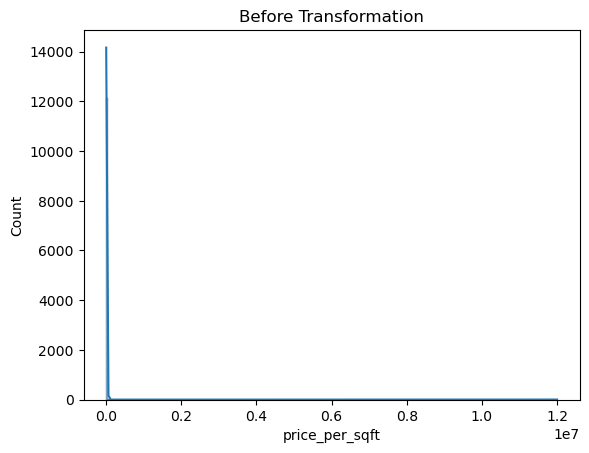

Skewness: 103.90203600448736
Kurtosis: 11135.813642004552


In [18]:
## histplot
sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Before Transformation")
plt.show()

print("Skewness:", df['price_per_sqft'].skew())
print("Kurtosis:", df['price_per_sqft'].kurt())

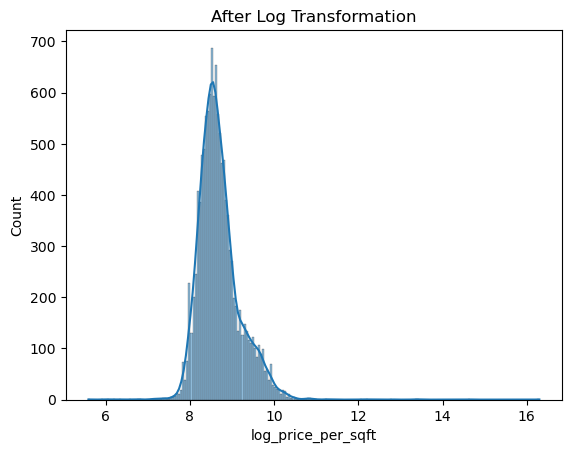

Skewness after: 1.40067811101755
Kurtosis after: 9.406497009619713


In [19]:
## Log Transformation
df['log_price_per_sqft'] = np.log(df['price_per_sqft'])

sns.histplot(df['log_price_per_sqft'], kde=True)
plt.title("After Log Transformation")
plt.show()

print("Skewness after:", df['log_price_per_sqft'].skew())
print("Kurtosis after:", df['log_price_per_sqft'].kurt())

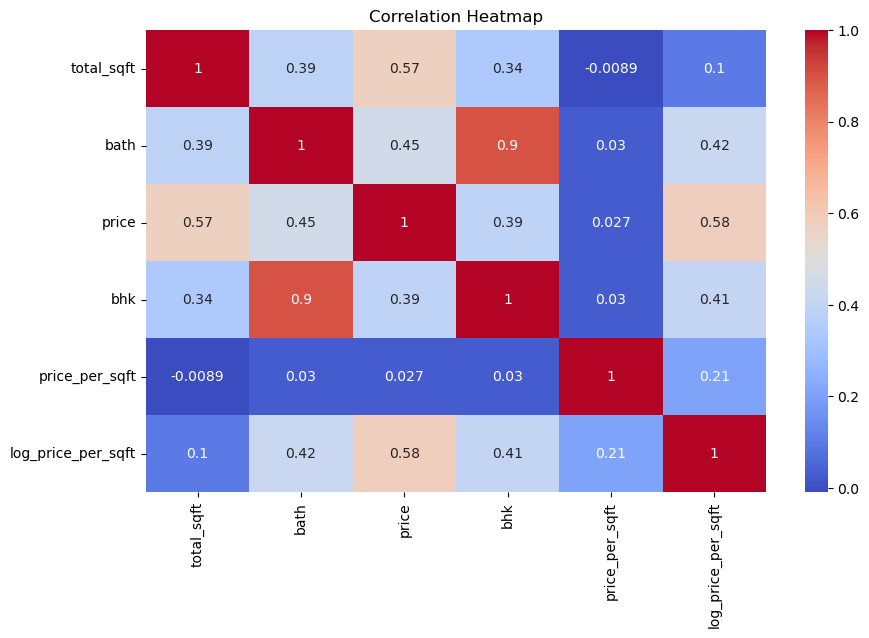

In [20]:
## Correlation & Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

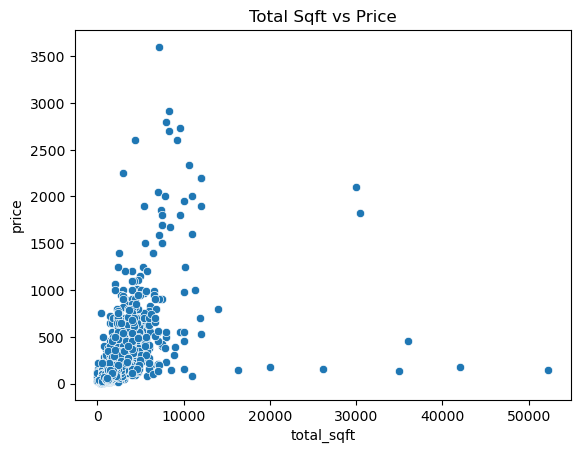

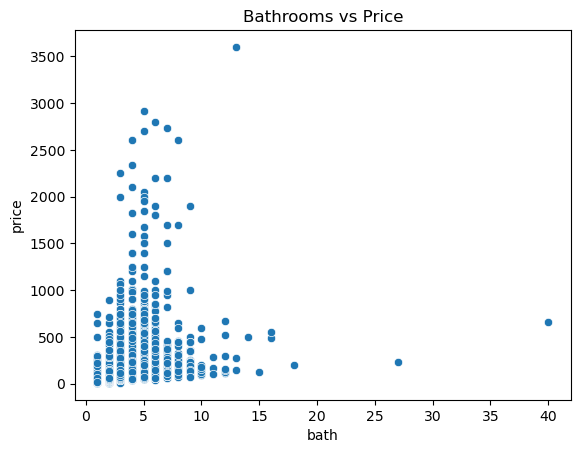

In [21]:
##Scatter Plots
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.title("Total Sqft vs Price")
plt.show()

sns.scatterplot(x='bath', y='price', data=df)
plt.title("Bathrooms vs Price")
plt.show()